In [1]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *

sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

# Importeren van de database

In [2]:
# Read into a pandas DataFrame
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.joinpath('database_all_v3.sqlite')))

dikes_and_projects.head()


,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
1,2,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
2,3,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
3,4,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
4,5,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22


In [3]:
#load data
df_final = load_and_merge_data(working_dir.joinpath('database_all_v3.sqlite'))

df_final.head()


,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,test_name_vs,test_id_vs,sample_name_vs,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat
8,9,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,T_H1R,24.0,H1R,9.1,9.3,1.391892,0.119432,2136.0,2085.0,1500.0
9,10,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,T_H2R,27.0,H2R,11.2,11.0,2.927273,0.125386,2726.0,2586.0,3000.0
10,11,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,T_H3R,30.0,H3R,14.6,15.3,0.805306,0.123694,1224.0,1105.0,5500.0
11,12,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,T_H4L,32.0,H4L,17.2,15.6,0.639710,0.119667,1229.0,1571.0,50000.0
12,13,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,T_H5R,35.0,H5R,11.8,11.5,1.599733,0.119253,2460.0,2211.0,18500.0


<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

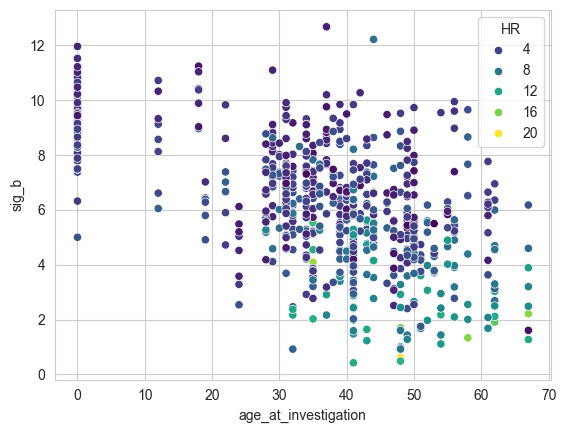

In [4]:
#make as scatter plot of age_at_investigation vs sig_b, colored by HR_category
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis')

In [5]:
#Export voor regressie
data_for_regression = df_final[['borehole_id','age_at_investigation', 'sig_b', 'HR']]
#rename sig_b to str and age_at_investigation to age and HR to void
data_for_regression = data_for_regression.rename(columns={'sig_b':'str', 'age_at_investigation':'age', 'HR':'void'})
#export to xlsx
data_for_regression.to_excel(working_dir.joinpath('data_for_regression.xlsx'), index=False)
                               
    

## Maken van dataframe op projectniveau

In [6]:
#make new df, grouped by project_id with mean and std for 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b', 'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber' 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat', 'HR_category```

data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)

data_per_dike_project.head()



KeyError: "Column(s) ['number_of_boreholes'] do not exist"

## Toevoegen van extra classificaties
Bros/ductiel (V_ber)
Sterk/gemiddeld/zwak (sig_b)
Heterogeniteit (o.b.v sig_b_CoV)

In [ ]:
#classificeren bros & ductiel op basis van sig_b en V_ber


df_final['HR_category'] = df_final['HR'].apply(categorize_hr)    
df_final['brittleness'] = df_final.apply(classify_brittleness, axis=1)
df_final['material_class'] = df_final.apply(classify_material_strength, axis=1)
df_final['construction_year_category'] = df_final.construction_year.apply(categorize_annum)
fig,ax = plt.subplots(figsize=(6, 6), ncols=1)
sns.scatterplot(data=df_final, x='V_Ber', y='sig_b', hue='brittleness',style='material_class', palette='tab10', ax=ax)


In [ ]:
data_per_dike_project['heterogeneity_category'] = data_per_dike_project['sig_b_cov'].apply(categorize_heterogeneity)

#scatterplot of age_at_investigation vs sig_b_mean, colored by heterogeneity_category
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='heterogeneity_category', palette='tab10')


In [ ]:
#heterogeniteitscategorie: maak een dict van project_dike_id en de corresponderende heterogeniteitscategorie o.b.v. data_per_dike_project
heterogeneity_dict = data_per_dike_project.set_index('project_dike_id')['heterogeneity_category'].to_dict()
heterogeneity_dict
#toevoegen aan df_final
df_final['heterogeneity_category'] = df_final['project_dike_id'].map(heterogeneity_dict)


# Analyses

## Filtering van de data/uitsluiten

### Impact uitsluiten van HR > 9%: welke punten verdwijnen?

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
threshold_hr = 9
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] < threshold_hr], x='age_at_investigation', y='sig_b', hue='HR',palette='viridis')
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] > 4], x='age_at_investigation', y='sig_b', color= 'orange', label = 'Niet relevant voor ontwerp')
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] > threshold_hr], x='age_at_investigation', y='sig_b', color= 'red', label = 'Verwijderde punten')
plt.legend()

### Heterogeniteit

In [ ]:
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='heterogeneity_category', palette='rocket', ax=ax[0])
sns.scatterplot(data=df_final, x='age_at_investigation', y='G_c', hue='heterogeneity_category', palette='rocket', ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[1].set_ylabel('Breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[0].set_ylim(0, 13)
ax[1].set_ylim(5, 10000)
ax[0].set_xlim(-0.5, 70)
ax[1].set_xlim(-0.5, 70)
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Heterogeen'], x='age_at_investigation', y='sig_b', hue='heterogeneity_category', palette=sns.color_palette('rocket',n_colors=3)[1:], ax=ax[0])
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Heterogeen'], x='age_at_investigation', y='G_c', hue='heterogeneity_category', palette=sns.color_palette('rocket',n_colors=3)[1:], ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[1].set_ylabel('Breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[0].set_ylim(0, 13)
ax[1].set_ylim(5, 10000)
ax[0].set_xlim(-0.5, 70)
ax[1].set_xlim(-0.5, 70)

In [ ]:
#same but for data_per_dike_project
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='heterogeneity_category', palette='rocket', ax=ax[0])
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='G_c_mean', hue='heterogeneity_category', palette='rocket', ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Gemiddelde buigtreksterkte (MPa)')
ax[1].set_ylabel('Gemiddelde breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')

In [ ]:
#check how often heterogeneity categories correspond to brittleness categories
df_final.groupby(['heterogeneity_category', 'brittleness']).size().unstack(fill_value=0)
#make a confusion matrix heatmap of the above
confusion_matrix = df_final.groupby(['heterogeneity_category', 'brittleness']).size().unstack(fill_value=0)
plt.figure(figsize=(8,6))
#ensure sequence of x is bros, overgang, ductiel and y is Homogeen, Matig heterogeen, Heterogeen. Normalize all values to sum to 1 in total
confusion_matrix = confusion_matrix.reindex(columns=['bros', 'overgang', 'ductiel'], index=['Homogeen', 'Matig heterogeen', 'Heterogeen'])
confusion_matrix = confusion_matrix.div(confusion_matrix.sum().sum(), axis=0)
sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Bros', 'Overgang', 'Ductiel'], yticklabels=['Homogeen', 'Matig heterogeen', 'Heterogeen'])
plt.xlabel('Brittleness Category')
plt.ylabel('Heterogeneity Category')
plt.title('Confusion Matrix of Heterogeneity vs Brittleness Categories')
plt.show()

## Construction year

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='construction_year_category', ax=ax, s=25, palette='Set2')

#make a confusion plot for construction year category vs heterogeneity category
confusion_matrix = df_final.groupby(['construction_year_category', 'heterogeneity_category']).size().unstack(fill_value=0)
#ensure sequence of x is Homogeen, Matig heterogeen, Heterogeen and y is before 1973, 1973-2000, after 2000
confusion_matrix = confusion_matrix.reindex(columns=['Homogeen', 'Matig heterogeen', 'Heterogeen'], index=['before 1973', '1973-2000', 'after 2000'])
#normalize all values to sum to 1 in total
# confusion_matrix = confusion_matrix.div(confusion_matrix.sum().sum(), axis=0)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt=".0f", cmap='RdBu_r', cbar=False)
plt.xlabel('Heterogeneity Category')
plt.ylabel('Construction Year Category')
plt.title('Confusion Matrix: Construction Year vs Heterogeneity')
plt.show()


## Pooling

### Algemeen

Eerst kijken naar de correlaties in de data

In [ ]:
# correlaties bij data_per_dike_project
data_per_dike_project[['Sec_10_mean', 'Sec_100_mean', 'sig_b_mean', 'eps_b_mean', 'G_c_mean', 'V_Ber_mean', 'pha_50_mean', 'E_50_mean', 'N_fat_mean', 'HR_mean']].corr()
#heatmaps of the correlations
plt.figure(figsize=(12,10))

sns.heatmap(data_per_dike_project[['Sec_10_mean', 'Sec_100_mean', 'sig_b_mean', 'eps_b_mean', 'G_c_mean','V_Ber_mean', 'pha_50_mean', 'E_50_mean', 'N_fat_mean', 'HR_mean']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Mean Values per Dike Project')


In [ ]:
#Breusch-Pagan Lagrange Multiplier test for heteroscedasticity
from xml.parsers.expat import model
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

#run on df_final
X = df_final[['age_at_investigation', 'HR']]
X = sm.add_constant(X)  # add constant term
y = df_final['sig_b']
model1 = sm.OLS(y, X).fit()
bp_test = het_breuschpagan(model1.resid, model1.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(bp_labels, bp_test)))

#run on df_final but without heterogeneneity category 'Heterogeen'
df_final_sub = df_final[df_final['heterogeneity_category'] != 'Heterogeen']
X = df_final_sub[['age_at_investigation', 'HR']]
X = sm.add_constant(X)  # add constant term
y = df_final_sub['sig_b']
model2 = sm.OLS(y, X).fit()
bp_test = het_breuschpagan(model2.resid, model2.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(bp_labels, bp_test)))

#plot both models and the data
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis', ax=ax[0])
#add regression line from model1
sns.regplot(x=df_final['age_at_investigation'], y=model1.fittedvalues, scatter=False, ax=ax[0], color='red', label='Regression Line')
#show residuals as vertical lines
for i in range(len(df_final)):
    ax[0].vlines(x=df_final['age_at_investigation'].iloc[i], ymin=model1.fittedvalues.iloc[i], ymax=df_final['sig_b'].iloc[i], color='gray', alpha=0.5)

#same for model2
sns.scatterplot(data=df_final_sub, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis', ax=ax[1])
#add regression line from model2
sns.regplot(x=df_final_sub['age_at_investigation'], y=model2.fittedvalues, scatter=False, ax=ax[1], color='red', label='Regression Line')

In [ ]:
#zelfde voor CoV
data_per_dike_project[['Sec_10_cov', 'Sec_100_cov', 'sig_b_cov', 'eps_b_cov', 'G_c_cov', 'V_Ber_cov', 'pha_50_cov', 'E_50_cov', 'N_fat_cov', 'HR_cov']].corr()
#heatmaps of the correlations
plt.figure(figsize=(12,10))
sns.heatmap(data_per_dike_project[['Sec_10_cov', 'Sec_100_cov', 'sig_b_cov', 'eps_b_cov', 'G_c_cov', 'V_Ber_cov', 'pha_50_cov', 'E_50_cov', 'N_fat_cov', 'HR_cov']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Coefficient of Variation per Dike Project')

In [ ]:
#compute correlation matrix of df_final for columns 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b', 'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber' 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat', 'age_at_investigation'
correlation_matrix_pearson = df_final[['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
# correlation_matrix_spearman = df_final[['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('kendall')
#plot correlation matrix as heatmap
fig, ax = plt.subplots(figsize=(10,10),)
sns.heatmap(correlation_matrix_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
# sns.heatmap(correlation_matrix_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
ax.set_title('Pearson correlatie voor dataset op sampleniveau')


In [ ]:
correlation_matrix_pearson_heterogeen = df_final.loc[df_final.heterogeneity_category == 'Heterogeen'][['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
correlation_matrix_pearson_homogeen = df_final.loc[df_final.heterogeneity_category == 'Homogeen'][['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
#plot both as heatmaps side by side
fig, ax = plt.subplots(figsize=(20,8), ncols=2)
sns.heatmap(correlation_matrix_pearson_heterogeen, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax[0])
sns.heatmap(correlation_matrix_pearson_homogeen, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax[1])
ax[0].set_title('Heterogeen')
ax[1].set_title('Homogeen')

### bros versus ductiel


In [ ]:
#pairplot of df_final with columns sig_b, V_Ber, pha_ini
g = sns.pairplot(df_final.loc[df_final.pha_ini < 1e6], vars=['sig_b', 'V_Ber', 'pha_ini'], hue='heterogeneity_category', palette='Set2', diag_kind='kde')
g.map_lower(sns.kdeplot, levels=4, color=".2")
#change y-labels to fasehoek, vormfactor en buigtreksterkte
g.axes[0,0].set_ylabel('Buigtreksterkte (MPa)')
g.axes[1,0].set_ylabel('Vormfactor')
g.axes[0,1].set_ylabel('Fasehoek (°)')
#same for xlabels
g.axes[0,0].set_xlabel('Buigtreksterkte (MPa)')
g.axes[1,0].set_xlabel('Vormfactor')
g.axes[0,1].set_xlabel('Fasehoek (°)')

plt.show()

### Regio

In [ ]:
df_final['waterboard'].unique()
#translation dictionary to get consistent names:
region_dict = {'Hollandse Delta': 'Zuid Hollandse Delta',
 'Rijkswaterstaat Zuid-Holland Waterdistrict Haringvliet': 'Zuid Hollandse Delta',
'Wetterskip Fryslân': 'Friesland', 
'Noorderzijlvest': 'Groningen',
"{'emmapolder_47,5 - 57': 'Noorderzijlvest'}": 'Groningen',
"{'noorderhavendam_0 - 1,206': 'Wetterskip Fryslân'}": "Friesland",
"HHNK": "Noord-Holland",
'Waterschap Noorderzijlvest': "Groningen",
"{'zuidelijke_dijken_goeree_vak_1_42,525 - 43,04': 'Hollandse Delta'}": 'Zuid Hollandse Delta',
'PWN': "Noord-Holland", 'Groningen Seaports': "Groningen", 'Waterschap Scheldestromen': "Zeeland",
'Waterschap Hollandse Delta': "Zuid Hollandse Delta", 'Rijkswaterstaat': "Rijkswaterstaat",
'Havenbedrijf Rotterdam': "Zuid Hollandse Delta", 'Waterschap Zuiderzeeland': "Flevoland"}
df_final['region'] = df_final['waterboard'].map(region_dict)

#make a distinction of data where region is Groningen or Friesland vs Noord-Holland, vs rest of the Netherlands
df_final['region_grouped'] = df_final['region'].apply(lambda x: 'Noord-Nederland' if x in ['Groningen', 'Friesland'] else ('Noord-Holland' if x == 'Noord-Holland' else 'Rest van Nederland'))

plot_data = df_final.loc[df_final.heterogeneity_category != 'Heterogeen']
#plot age_at_investigation vs sig_b, colored by region
fig,ax= plt.subplots(figsize=(10,6))
sns.scatterplot(data=plot_data, x='age_at_investigation', y='sig_b', hue='region_grouped', palette='tab10',ax=ax)
#make simple regression line for each region_grouped
sns.regplot(data=plot_data.loc[plot_data['region_grouped'] == 'Noord-Nederland'], x='age_at_investigation', y='sig_b', ci=None,ax=ax, scatter=False)
sns.regplot(data=plot_data.loc[plot_data['region_grouped'] == 'Noord-Holland'], x='age_at_investigation', y='sig_b', ci=None,ax=ax, scatter=False)
sns.regplot(data=plot_data.loc[plot_data['region_grouped'] == 'Rest van Nederland'], x='age_at_investigation', y='sig_b', ci=None,ax=ax, scatter=False)

#also map to data_per_dike_project
data_per_dike_project['region'] = data_per_dike_project['waterboard'].map(region_dict)
data_per_dike_project['region_grouped'] = data_per_dike_project['region'].apply(lambda x: 'Noord-Nederland' if x in ['Groningen', 'Friesland'] else ('Noord-Holland' if x == 'Noord-Holland' else 'Rest van Nederland'))
plot_data_region = data_per_dike_project.loc[data_per_dike_project.heterogeneity_category != 'Heterogeen']
#plot age_at_investigation vs sig_b_mean, colored by 
plt.subplots()
sns.scatterplot(data=plot_data_region, x='age_at_investigation', y='sig_b_mean', hue='region_grouped', palette='tab10')
#also regplots here
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Nederland'], x='age_at_investigation', y='sig_b_mean', ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Holland'], x='age_at_investigation', y='sig_b_mean', ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Rest van Nederland'], x='age_at_investigation', y='sig_b_mean', ci=None, scatter=False)


#also make it for sig_b_cov
plt.subplots()
sns.scatterplot(data=plot_data_region, x='age_at_investigation', y='sig_b_cov', hue='region_grouped', palette='tab10')
#also regplots here
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Nederland'], x='age_at_investigation', y='sig_b_cov',
            ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Holland'], x='age_at_investigation', y='sig_b_cov',
            ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Rest van Nederland'], x='age_at_investigation', y='sig_b_cov',
            ci=None, scatter=False)

#plot the distributions for each region_grouped
fig, ax = plt.subplots(figsize=(15,5), ncols=3)
sns.histplot(data=plot_data, x='sig_b', hue='region_grouped', palette='tab10', ax=ax[0], bins=30, kde=True,hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data, x='G_c', hue='region_grouped', palette='tab10', ax=ax[1], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data, x='V_Ber', hue='region_grouped', palette='tab10', ax=ax[2], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
ax[0].set_title('Buigtreksterkte (MPa)')
ax[1].set_title('Breukenergie (J/m^2)')
ax[2].set_title('Vormfactor')
ax[1].set_xscale('log')

## Wat voorspellen we?

In [ ]:
# pd.DataFrame(df_final.dike_name.unique(), columns=['dike_name']).to_excel(working_dir.joinpath('dike_names.xlsx'), index=False)
#load the matrix of dike names and whether they are connected or not (1 means connected)
dike_connections = pd.read_excel(working_dir.parent.joinpath('data','dike_connections.xlsx'))
dike_connections.set_index('dike_name', inplace=True)
#make a list of dike names and the number of corresponding dike_names by summing by row
dike_connections['num_connections'] = dike_connections.sum(axis=1)

In [ ]:
dike_connections[['num_connections']].sort_values('num_connections', ascending=False).head(10)

#for each dike_name in dike_connections where num_connections > 1: select the data from df_final where dike_name is that dike_name or any of the connected dike_names
#make a list of the index such that we can pop the sections already plotted
plotted_for = [] 
dike_list = dike_connections.index.tolist()
#also make a list of dike_names where there are multiple project_id's for the same dike_name
multiple_projects = dikes_and_projects.groupby('dike_name')['project_id'].nunique()
multiple_projects = multiple_projects[multiple_projects > 1].index.tolist()

for count, dike in enumerate(dike_list):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
        connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
        dike_data = df_final[df_final['dike_name'].isin(connected_dikes + [dike])]
        #make a scatterplot of age_at_investigation vs sig_b, colored by dike_name
        fig, ax = plt.subplots(figsize=(6,6))
        #add age_since_first_investigation column
        dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
        #add boxplot for each of the unique values of age_at_investigation, make sure that boxplots align on x-axis
        sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='sig_b', hue='dike_name', palette='tab10',ax=ax,zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b', ci=None, scatter=False, ax=ax, color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   

        ax.set_title(f'Data for {dike} and connected dikes')
        ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
        ax.set_ylabel('Buigtreksterkte (MPa)')
        ax.set_xlim(-0.5, 70)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        #fix x_ticks to be integers at the right positions
        ax.set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax.set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])
        plt.savefig(results_dir.joinpath(f'timeseries_per_section/{dike}_and_connected_dikes.png'), bbox_inches='tight')
        plt.close()

        plotted_for.append((dike, len(connected_dikes)))
        #pop the dike and connected dikes from the dike_list
        for cd in connected_dikes:
            if cd in dike_list:
                dike_list.remove(cd)

#print table with name and number of connected dikes

pd.DataFrame(plotted_for, columns=['dike_name', 'num_connected_dikes']).to_csv(results_dir.joinpath('timeseries_per_section','plotted_dike_sections.csv'), index=False)